# MuSe-Physio Pipeline and Model Results EDA

This notebook analyzes the full current experiment pipeline:

- processed MuSe-Physio data contract;
- teacher, small student, and KD baselines;
- missing-modality experiments;
- KD versus no-KD comparisons;
- teacher-sized student behavior under missing modalities;
- training dynamics and metric tradeoffs.

Run the notebook from the repository root or from inside `notebooks/`; the path setup cell will locate the project automatically.

In [2]:
from __future__ import annotations

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 180,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "font.size": 10,
})


def find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (
            (candidate / "outputs" / "missing_modality_results_summary.csv").exists()
            and (candidate / "Processed_dataset" / "muse_physio_baseline" / "manifest.json").exists()
        ):
            return candidate
    raise FileNotFoundError("Could not locate repository root from current working directory.")


REPO_ROOT = find_repo_root()
SUMMARY_PATH = REPO_ROOT / "outputs" / "missing_modality_results_summary.csv"
MANIFEST_PATH = REPO_ROOT / "Processed_dataset" / "muse_physio_baseline" / "manifest.json"
NORM_STATS_PATH = REPO_ROOT / "Processed_dataset" / "muse_physio_baseline" / "feature_normalization_stats.csv"
NOTEBOOK_OUTPUT_DIR = REPO_ROOT / "outputs" / "eda_pipeline_report" / "notebook_graphs"
NOTEBOOK_TABLE_DIR = REPO_ROOT / "outputs" / "eda_pipeline_report" / "notebook_tables"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Repository:", REPO_ROOT)
print("Graphs will be saved to:", NOTEBOOK_OUTPUT_DIR)

Repository: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition
Graphs will be saved to: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs


In [3]:
RUN_LABELS = {
    "teacher_full": "Teacher full",
    "student_full_no_kd": "Small full, no KD",
    "student_full_kd": "Small full, KD",
    "student_missing_bpm": "Small no KD, missing BPM",
    "student_missing_ecg": "Small no KD, missing ECG",
    "student_missing_resp": "Small no KD, missing RESP",
    "student_kd_missing_bpm": "Small KD, missing BPM",
    "student_kd_missing_ecg": "Small KD, missing ECG",
    "student_kd_missing_resp": "Small KD, missing RESP",
    "teacher_sized_student_kd_missing_bpm": "Teacher-sized KD, missing BPM",
    "teacher_sized_student_kd_missing_ecg": "Teacher-sized KD, missing ECG",
    "teacher_sized_student_kd_missing_resp": "Teacher-sized KD, missing RESP",
}

FAMILY_LABELS = {
    "teacher_full": "Teacher",
    "student_full_no_kd": "Small no KD",
    "student_full_kd": "Small KD",
    "student_missing_bpm": "Small no KD",
    "student_missing_ecg": "Small no KD",
    "student_missing_resp": "Small no KD",
    "student_kd_missing_bpm": "Small KD",
    "student_kd_missing_ecg": "Small KD",
    "student_kd_missing_resp": "Small KD",
    "teacher_sized_student_kd_missing_bpm": "Teacher-sized KD",
    "teacher_sized_student_kd_missing_ecg": "Teacher-sized KD",
    "teacher_sized_student_kd_missing_resp": "Teacher-sized KD",
}

FAMILY_COLORS = {
    "Teacher": "#34495e",
    "Small no KD": "#4c78a8",
    "Small KD": "#f58518",
    "Teacher-sized KD": "#54a24b",
}

CONDITION_ORDER = ["missing_bpm", "missing_ecg", "missing_resp"]
CONDITION_LABELS = {
    "full": "Full input",
    "missing_bpm": "Missing BPM",
    "missing_ecg": "Missing ECG",
    "missing_resp": "Missing RESP",
}
AVAILABLE_LABELS = {
    "full": "BPM + ECG + RESP",
    "missing_bpm": "ECG + RESP",
    "missing_ecg": "BPM + RESP",
    "missing_resp": "BPM + ECG",
}

METRICS = {
    "ccc": {"label": "CCC", "better": "higher"},
    "mse": {"label": "MSE", "better": "lower"},
    "mae": {"label": "MAE", "better": "lower"},
    "pearson": {"label": "Pearson", "better": "higher"},
    "mean_participant_ccc": {"label": "Mean participant CCC", "better": "higher"},
}


def savefig(name: str) -> Path:
    path = NOTEBOOK_OUTPUT_DIR / name
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    plt.show()
    print("saved:", path)
    return path


def modality_text(value, condition: str) -> str:
    if isinstance(value, str) and value.strip():
        return value.replace("|", " + ")
    return AVAILABLE_LABELS.get(condition, "")


def count_checkpoint_parameters(output_dir: str) -> int | None:
    checkpoint_path = REPO_ROOT / output_dir / "best.pt"
    if not checkpoint_path.exists():
        return None
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    return int(sum(tensor.numel() for tensor in checkpoint["model_state"].values()))


def load_results() -> pd.DataFrame:
    data = pd.read_csv(SUMMARY_PATH)
    for column in METRICS:
        data[column] = pd.to_numeric(data[column], errors="coerce")
    data["display_name"] = data["run_name"].map(RUN_LABELS).fillna(data["run_name"])
    data["family"] = data["run_name"].map(FAMILY_LABELS).fillna(data["capacity"])
    data["condition_label"] = data["condition"].map(CONDITION_LABELS)
    data["available_modalities_text"] = [
        modality_text(value, condition)
        for value, condition in zip(data["available_modalities"], data["condition"])
    ]
    data["parameter_count"] = [
        count_checkpoint_parameters(path) if status == "complete" else None
        for path, status in zip(data["output_dir"], data["status"])
    ]
    data["parameter_millions"] = data["parameter_count"].astype(float) / 1_000_000
    data["ccc_per_million_params"] = data["ccc"] / data["parameter_millions"]
    return data


def load_histories(results: pd.DataFrame) -> pd.DataFrame:
    histories = []
    for row in results.itertuples(index=False):
        history_path = REPO_ROOT / row.output_dir / "history.csv"
        if not history_path.exists():
            continue
        history = pd.read_csv(history_path)
        history["run_name"] = row.run_name
        history["display_name"] = row.display_name
        history["family"] = row.family
        history["condition"] = row.condition
        history["condition_label"] = row.condition_label
        history["available_modalities_text"] = row.available_modalities_text
        histories.append(history)
    return pd.concat(histories, ignore_index=True) if histories else pd.DataFrame()


def compute_small_kd_deltas(results: pd.DataFrame) -> pd.DataFrame:
    pairs = [
        ("full", "student_full_no_kd", "student_full_kd"),
        ("missing_bpm", "student_missing_bpm", "student_kd_missing_bpm"),
        ("missing_ecg", "student_missing_ecg", "student_kd_missing_ecg"),
        ("missing_resp", "student_missing_resp", "student_kd_missing_resp"),
    ]
    rows = []
    for condition, no_kd_name, kd_name in pairs:
        no_kd = results.loc[results["run_name"] == no_kd_name].iloc[0]
        kd = results.loc[results["run_name"] == kd_name].iloc[0]
        row = {
            "condition": condition,
            "condition_label": CONDITION_LABELS[condition],
            "available_modalities": AVAILABLE_LABELS[condition],
        }
        for metric in METRICS:
            row[f"no_kd_{metric}"] = no_kd[metric]
            row[f"kd_{metric}"] = kd[metric]
            row[f"{metric}_delta"] = kd[metric] - no_kd[metric]
        rows.append(row)
    return pd.DataFrame(rows)


def compute_capacity_deltas(results: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for condition in CONDITION_ORDER:
        small = results[(results["condition"] == condition) & (results["family"] == "Small KD")].iloc[0]
        large = results[(results["condition"] == condition) & (results["family"] == "Teacher-sized KD")].iloc[0]
        row = {
            "condition": condition,
            "condition_label": CONDITION_LABELS[condition],
            "available_modalities": AVAILABLE_LABELS[condition],
        }
        for metric in METRICS:
            row[f"small_kd_{metric}"] = small[metric]
            row[f"teacher_sized_kd_{metric}"] = large[metric]
            row[f"{metric}_delta"] = large[metric] - small[metric]
        rows.append(row)
    return pd.DataFrame(rows)


def plot_heatmap(matrix: pd.DataFrame, title: str, cmap: str = "viridis", fmt: str = ".3f") -> None:
    fig, ax = plt.subplots(figsize=(9, 4.8))
    values = matrix.to_numpy(dtype=float)
    image = ax.imshow(values, aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(matrix.shape[1]), matrix.columns, rotation=25, ha="right")
    ax.set_yticks(np.arange(matrix.shape[0]), matrix.index)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            value = values[i, j]
            if np.isfinite(value):
                ax.text(j, i, format(value, fmt), ha="center", va="center", color="white", fontsize=9)
    ax.set_title(title)
    plt.colorbar(image, ax=ax, fraction=0.035, pad=0.04)

In [4]:
results = load_results()
histories = load_histories(results)
small_kd_delta = compute_small_kd_deltas(results)
capacity_delta = compute_capacity_deltas(results)
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))
norm_stats = pd.read_csv(NORM_STATS_PATH)

results.to_csv(NOTEBOOK_TABLE_DIR / "notebook_model_results.csv", index=False)
small_kd_delta.to_csv(NOTEBOOK_TABLE_DIR / "notebook_small_kd_deltas.csv", index=False)
capacity_delta.to_csv(NOTEBOOK_TABLE_DIR / "notebook_capacity_deltas.csv", index=False)

display(Markdown("## Loaded result tables"))
display(results[[
    "display_name", "family", "condition_label", "available_modalities_text",
    "uses_kd", "parameter_count", "best_epoch", "ccc", "mse", "mae", "pearson",
    "mean_participant_ccc",
]].sort_values("ccc", ascending=False))

display(Markdown("### KD deltas for small students"))
display(small_kd_delta)

display(Markdown("### Teacher-sized KD capacity deltas"))
display(capacity_delta)

## Loaded result tables

,display_name,family,condition_label,available_modalities_text,uses_kd,parameter_count,best_epoch,ccc,mse,mae,pearson,mean_participant_ccc
11,"Teacher-sized KD, missing RESP",Teacher-sized KD,Missing RESP,BPM + ECG,True,661761,12,0.364222,0.200656,0.355126,0.375373,0.086136
8,"Small KD, missing RESP",Small KD,Missing RESP,BPM + ECG,True,132865,13,0.325058,0.191864,0.342891,0.326643,-0.000565
5,"Small no KD, missing RESP",Small no KD,Missing RESP,BPM + ECG,False,132865,17,0.316734,0.196515,0.344066,0.323267,0.003588
0,Teacher full,Teacher,Full input,BPM + ECG + RESP,False,661889,49,0.302021,0.158668,0.305578,0.318660,0.066564
10,"Teacher-sized KD, missing ECG",Teacher-sized KD,Missing ECG,BPM + RESP,True,661761,19,0.246920,0.257720,0.382943,0.255179,-0.000067
9,"Teacher-sized KD, missing BPM",Teacher-sized KD,Missing BPM,ECG + RESP,True,661761,10,0.212279,0.271177,0.423851,0.244443,0.007513
1,"Small full, no KD",Small no KD,Full input,BPM + ECG + RESP,False,132929,3,0.208552,0.542295,0.579393,0.273103,0.023588
2,"Small full, KD",Small KD,Full input,BPM + ECG + RESP,True,132929,19,0.199364,0.244818,0.383044,0.207801,-0.018553
7,"Small KD, missing ECG",Small KD,Missing ECG,BPM + RESP,True,132865,7,0.130009,0.320876,0.416688,0.136561,-0.002130
4,"Small no KD, missing ECG",Small no KD,Missing ECG,BPM + RESP,False,132865,7,0.124443,0.378240,0.468636,0.136191,-0.037993


### KD deltas for small students

,condition,condition_label,available_modalities,no_kd_ccc,kd_ccc,ccc_delta,no_kd_mse,kd_mse,mse_delta,no_kd_mae,kd_mae,mae_delta,no_kd_pearson,kd_pearson,pearson_delta,no_kd_mean_participant_ccc,kd_mean_participant_ccc,mean_participant_ccc_delta
0,full,Full input,BPM + ECG + RESP,0.208552,0.199364,-0.009188,0.542295,0.244818,-0.297477,0.579393,0.383044,-0.196348,0.273103,0.207801,-0.065302,0.023588,-0.018553,-0.042141
1,missing_bpm,Missing BPM,ECG + RESP,0.112136,0.102347,-0.009789,0.228560,0.225323,-0.003237,0.379207,0.380310,0.001103,0.135908,0.120787,-0.015121,0.039346,0.006784,-0.032561
2,missing_ecg,Missing ECG,BPM + RESP,0.124443,0.130009,0.005566,0.378240,0.320876,-0.057364,0.468636,0.416688,-0.051948,0.136191,0.136561,0.000370,-0.037993,-0.002130,0.035863
3,missing_resp,Missing RESP,BPM + ECG,0.316734,0.325058,0.008323,0.196515,0.191864,-0.004651,0.344066,0.342891,-0.001175,0.323267,0.326643,0.003376,0.003588,-0.000565,-0.004152


### Teacher-sized KD capacity deltas

,condition,condition_label,available_modalities,small_kd_ccc,teacher_sized_kd_ccc,ccc_delta,small_kd_mse,teacher_sized_kd_mse,mse_delta,small_kd_mae,teacher_sized_kd_mae,mae_delta,small_kd_pearson,teacher_sized_kd_pearson,pearson_delta,small_kd_mean_participant_ccc,teacher_sized_kd_mean_participant_ccc,mean_participant_ccc_delta
0,missing_bpm,Missing BPM,ECG + RESP,0.102347,0.212279,0.109933,0.225323,0.271177,0.045854,0.380310,0.423851,0.043541,0.120787,0.244443,0.123656,0.006784,0.007513,0.000729
1,missing_ecg,Missing ECG,BPM + RESP,0.130009,0.246920,0.116911,0.320876,0.257720,-0.063156,0.416688,0.382943,-0.033746,0.136561,0.255179,0.118618,-0.002130,-0.000067,0.002063
2,missing_resp,Missing RESP,BPM + ECG,0.325058,0.364222,0.039164,0.191864,0.200656,0.008792,0.342891,0.355126,0.012235,0.326643,0.375373,0.048730,-0.000565,0.086136,0.086701


## 1. Pipeline Graphs

These graphs check what the preprocessing pipeline produced: participant/sample counts, target/padding balance, and feature normalization values.

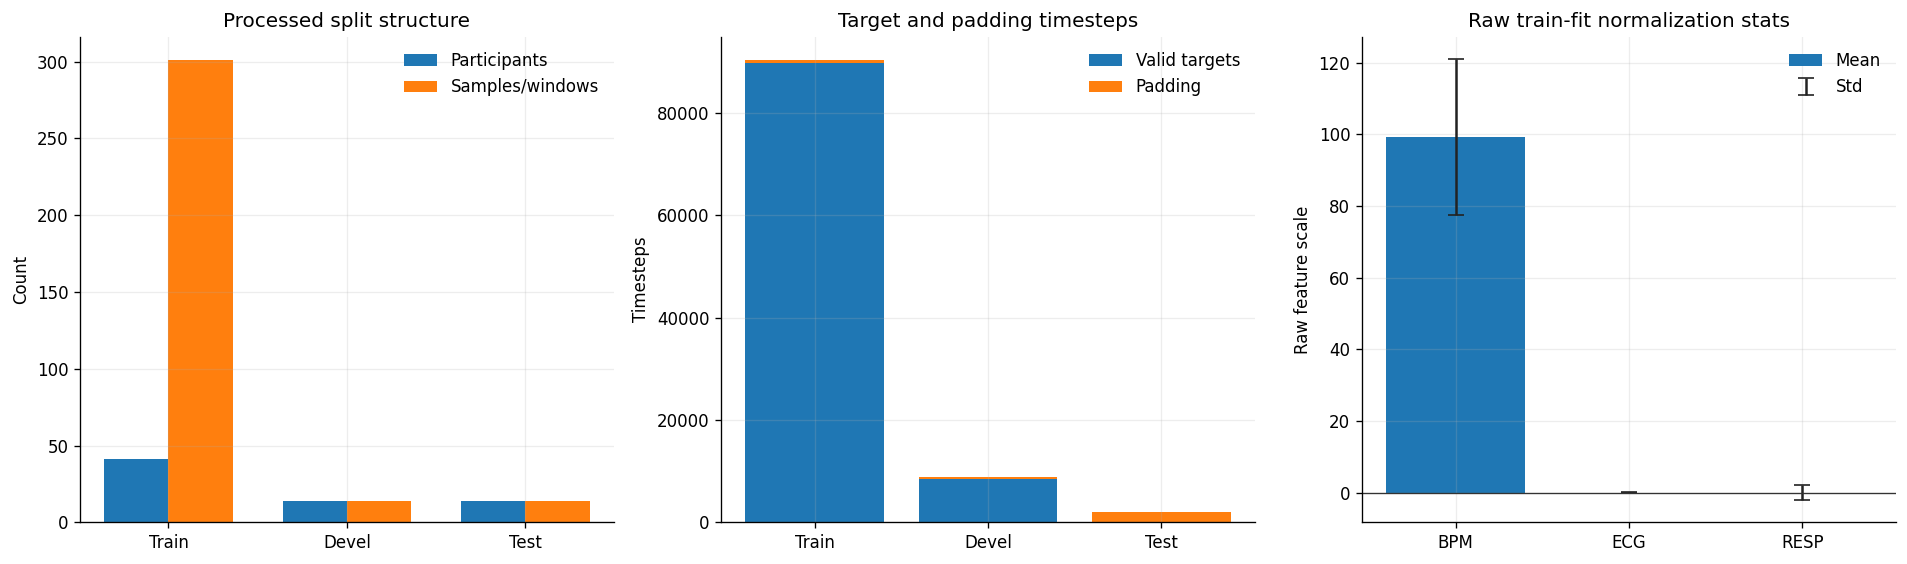

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\01_pipeline_overview_and_normalization.png


,split,participants,samples,x_shape,padding_steps,valid_target_steps
0,train,41,301,"[301, 300, 3]",588,89712
1,devel,14,14,"[14, 628, 3]",292,8500
2,test,14,14,"[14, 748, 3]",1990,0


,modality,mean,std,fit_split,unique_frames_used
0,BPM,99.236190,21.746166,train,24712
1,ECG,-0.002919,0.129863,train,24712
2,RESP,-0.008485,2.091650,train,24712


In [5]:
split_rows = [{"split": split, **summary} for split, summary in manifest["splits"].items()]
splits = pd.DataFrame(split_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
x = np.arange(len(splits))

axes[0].bar(x - 0.18, splits["participants"], width=0.36, label="Participants")
axes[0].bar(x + 0.18, splits["samples"], width=0.36, label="Samples/windows")
axes[0].set_xticks(x, splits["split"].str.title())
axes[0].set_title("Processed split structure")
axes[0].set_ylabel("Count")
axes[0].legend(frameon=False)

axes[1].bar(x, splits["valid_target_steps"], label="Valid targets")
axes[1].bar(x, splits["padding_steps"], bottom=splits["valid_target_steps"], label="Padding")
axes[1].set_xticks(x, splits["split"].str.title())
axes[1].set_title("Target and padding timesteps")
axes[1].set_ylabel("Timesteps")
axes[1].legend(frameon=False)

axes[2].bar(norm_stats["modality"], norm_stats["mean"], label="Mean")
axes[2].errorbar(norm_stats["modality"], norm_stats["mean"], yerr=norm_stats["std"], fmt="none", color="#222222", capsize=5, label="Std")
axes[2].axhline(0, color="#333333", linewidth=0.8)
axes[2].set_title("Raw train-fit normalization stats")
axes[2].set_ylabel("Raw feature scale")
axes[2].legend(frameon=False)

savefig("01_pipeline_overview_and_normalization.png")

display(splits[["split", "participants", "samples", "x_shape", "padding_steps", "valid_target_steps"]])
display(norm_stats)

## 2. All-Model Metric Graphs

These plots rank every saved model by each metric. CCC and Pearson are agreement/correlation metrics where higher is better; MSE and MAE are error metrics where lower is better.

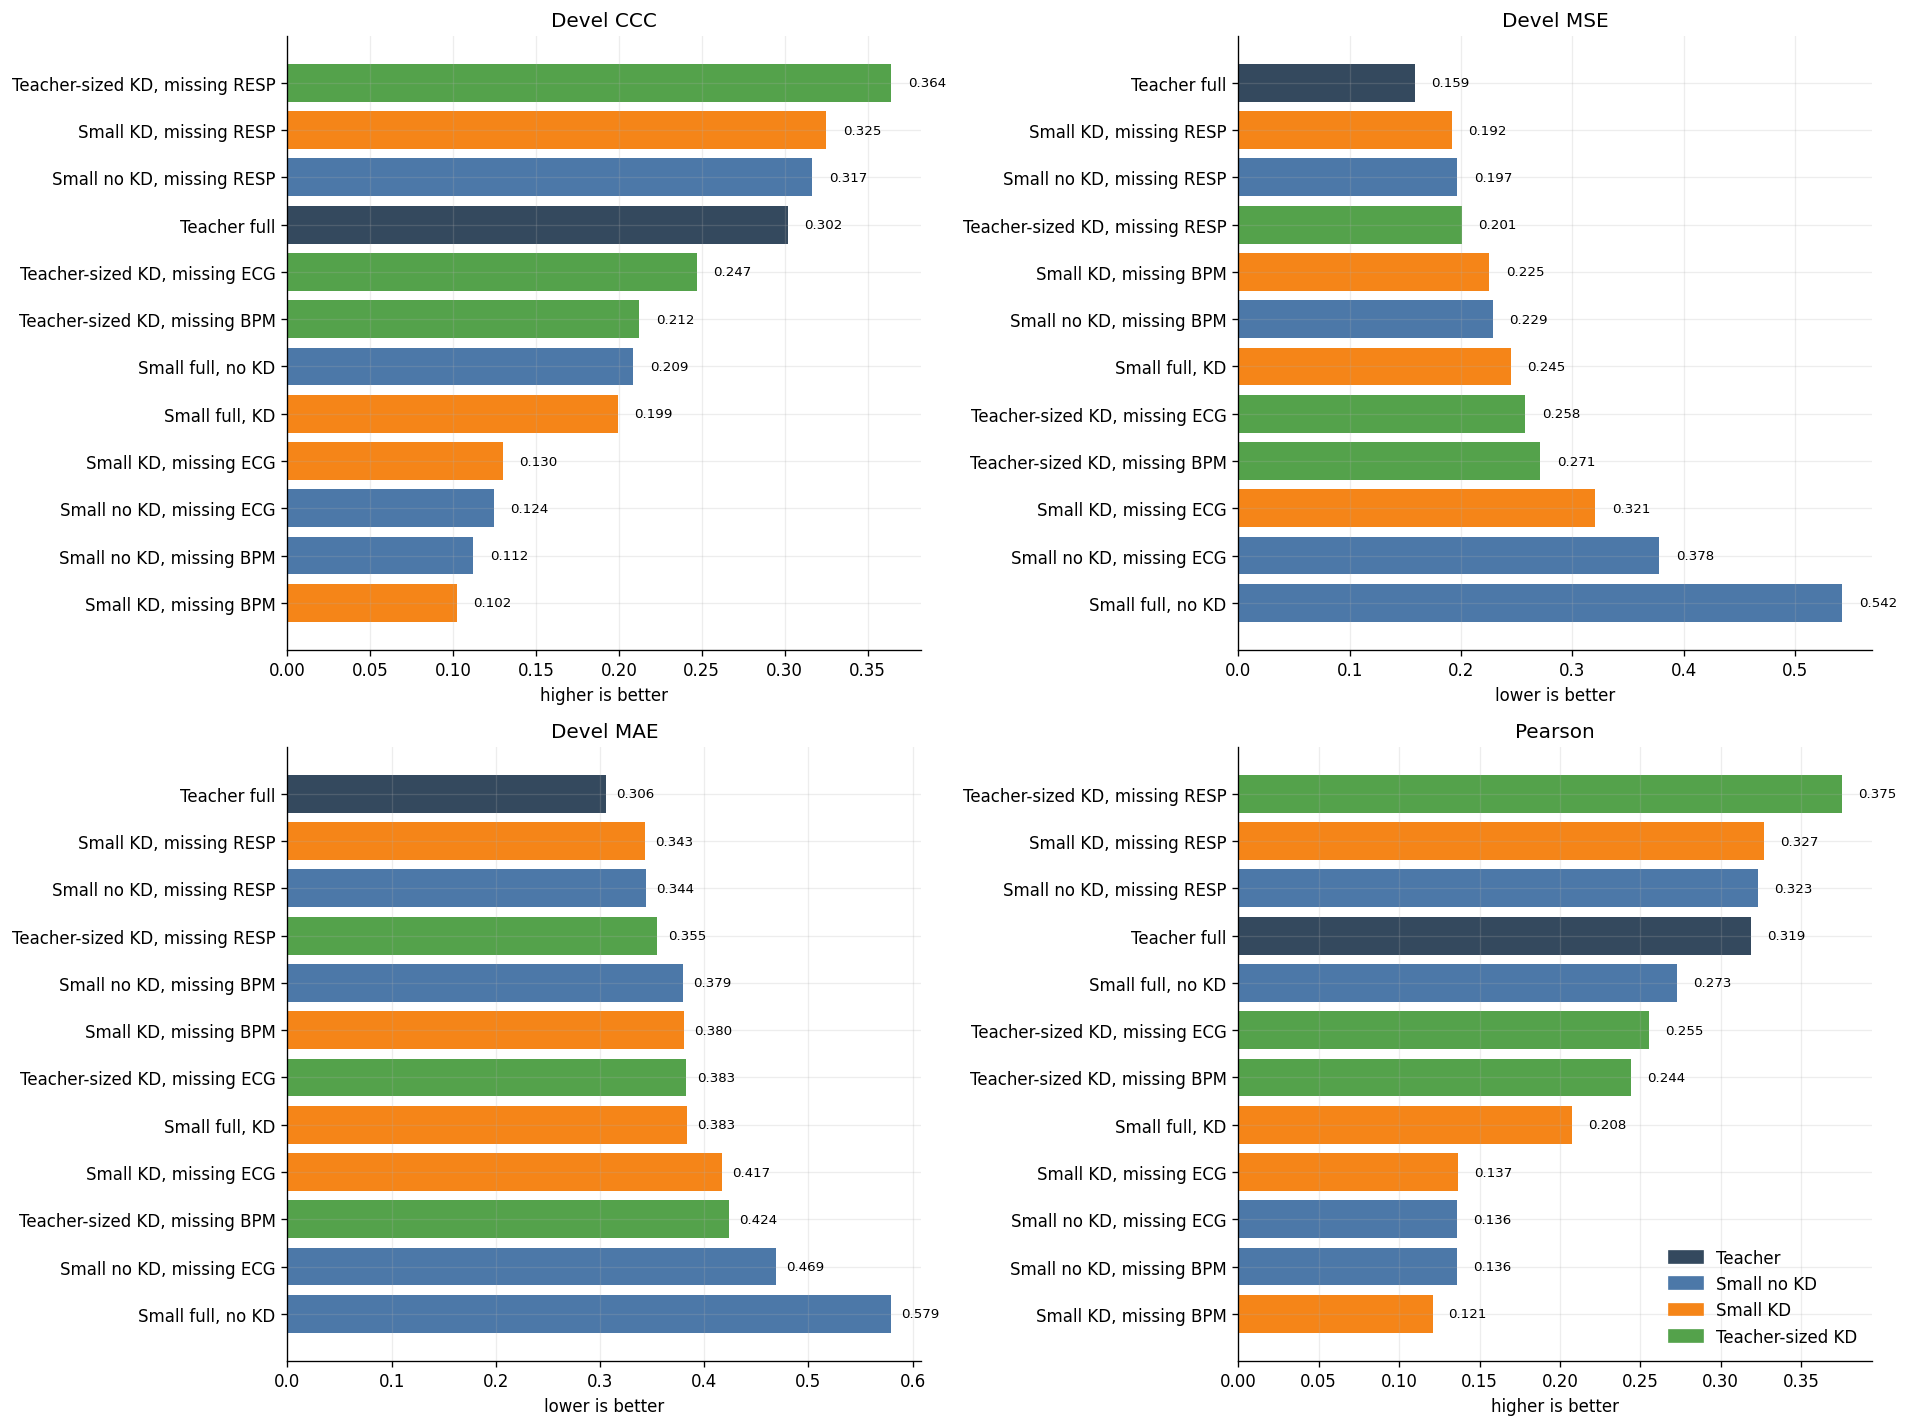

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\02_all_models_metric_rankings.png


WindowsPath('C:/Users/Victus/Documents/GitHub/Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition/outputs/eda_pipeline_report/notebook_graphs/02_all_models_metric_rankings.png')

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metric_grid = [("ccc", "Devel CCC"), ("mse", "Devel MSE"), ("mae", "Devel MAE"), ("pearson", "Pearson")]

for ax, (metric, title) in zip(axes.flat, metric_grid):
    ascending = metric in {"ccc", "pearson"}
    data = results.sort_values(metric, ascending=ascending)
    colors = [FAMILY_COLORS.get(family, "#888888") for family in data["family"]]
    bars = ax.barh(data["display_name"], data[metric], color=colors)
    ax.set_title(title)
    ax.set_xlabel(METRICS[metric]["better"] + " is better")
    for bar, value in zip(bars, data[metric]):
        offset = 0.01 if metric != "mse" else 0.015
        ax.text(value + offset, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center", fontsize=8)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in FAMILY_COLORS.values()]
axes[1, 1].legend(legend_handles, list(FAMILY_COLORS.keys()), frameon=False, loc="lower right")
savefig("02_all_models_metric_rankings.png")

## 3. Missing-Modality Graphs

These graphs compare model families under each two-modality input condition.

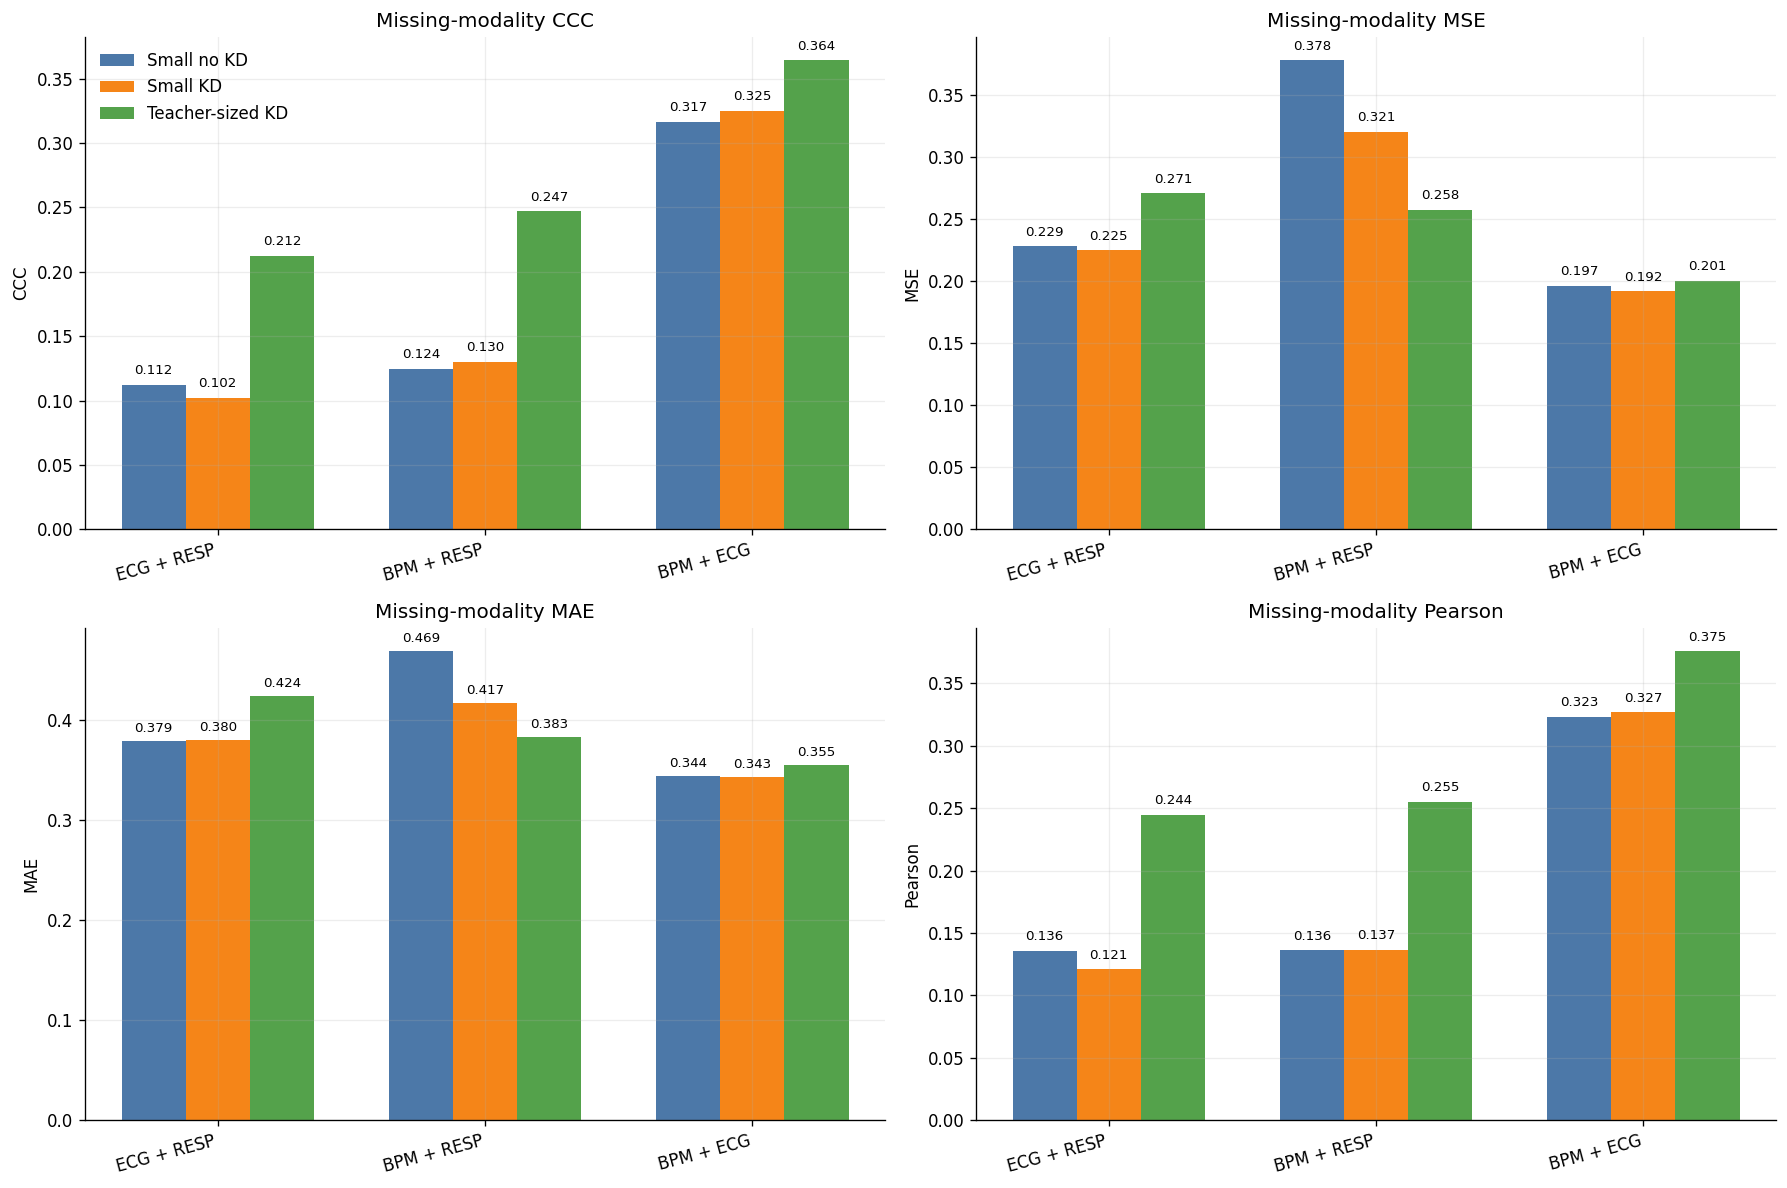

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\03_missing_modality_metrics_by_family.png


WindowsPath('C:/Users/Victus/Documents/GitHub/Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition/outputs/eda_pipeline_report/notebook_graphs/03_missing_modality_metrics_by_family.png')

In [7]:
missing = results[results["condition"].isin(CONDITION_ORDER)].copy()
family_order = ["Small no KD", "Small KD", "Teacher-sized KD"]
condition_labels = [AVAILABLE_LABELS[condition] for condition in CONDITION_ORDER]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
for ax, metric in zip(axes.flat, ["ccc", "mse", "mae", "pearson"]):
    x = np.arange(len(CONDITION_ORDER))
    width = 0.24
    for idx, family in enumerate(family_order):
        values = []
        for condition in CONDITION_ORDER:
            match = missing[(missing["condition"] == condition) & (missing["family"] == family)]
            values.append(float(match[metric].iloc[0]) if not match.empty else np.nan)
        bars = ax.bar(x + (idx - 1) * width, values, width=width, label=family, color=FAMILY_COLORS[family])
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, value + 0.006, f"{value:.3f}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x, condition_labels, rotation=15, ha="right")
    ax.set_title(f"Missing-modality {METRICS[metric]['label']}")
    ax.set_ylabel(METRICS[metric]["label"])
axes[0, 0].legend(frameon=False)
savefig("03_missing_modality_metrics_by_family.png")

## 4. KD Versus No-KD Graphs

These graphs directly answer: did KD improve the small student? Positive CCC/Pearson deltas are good; negative MSE/MAE deltas are good.

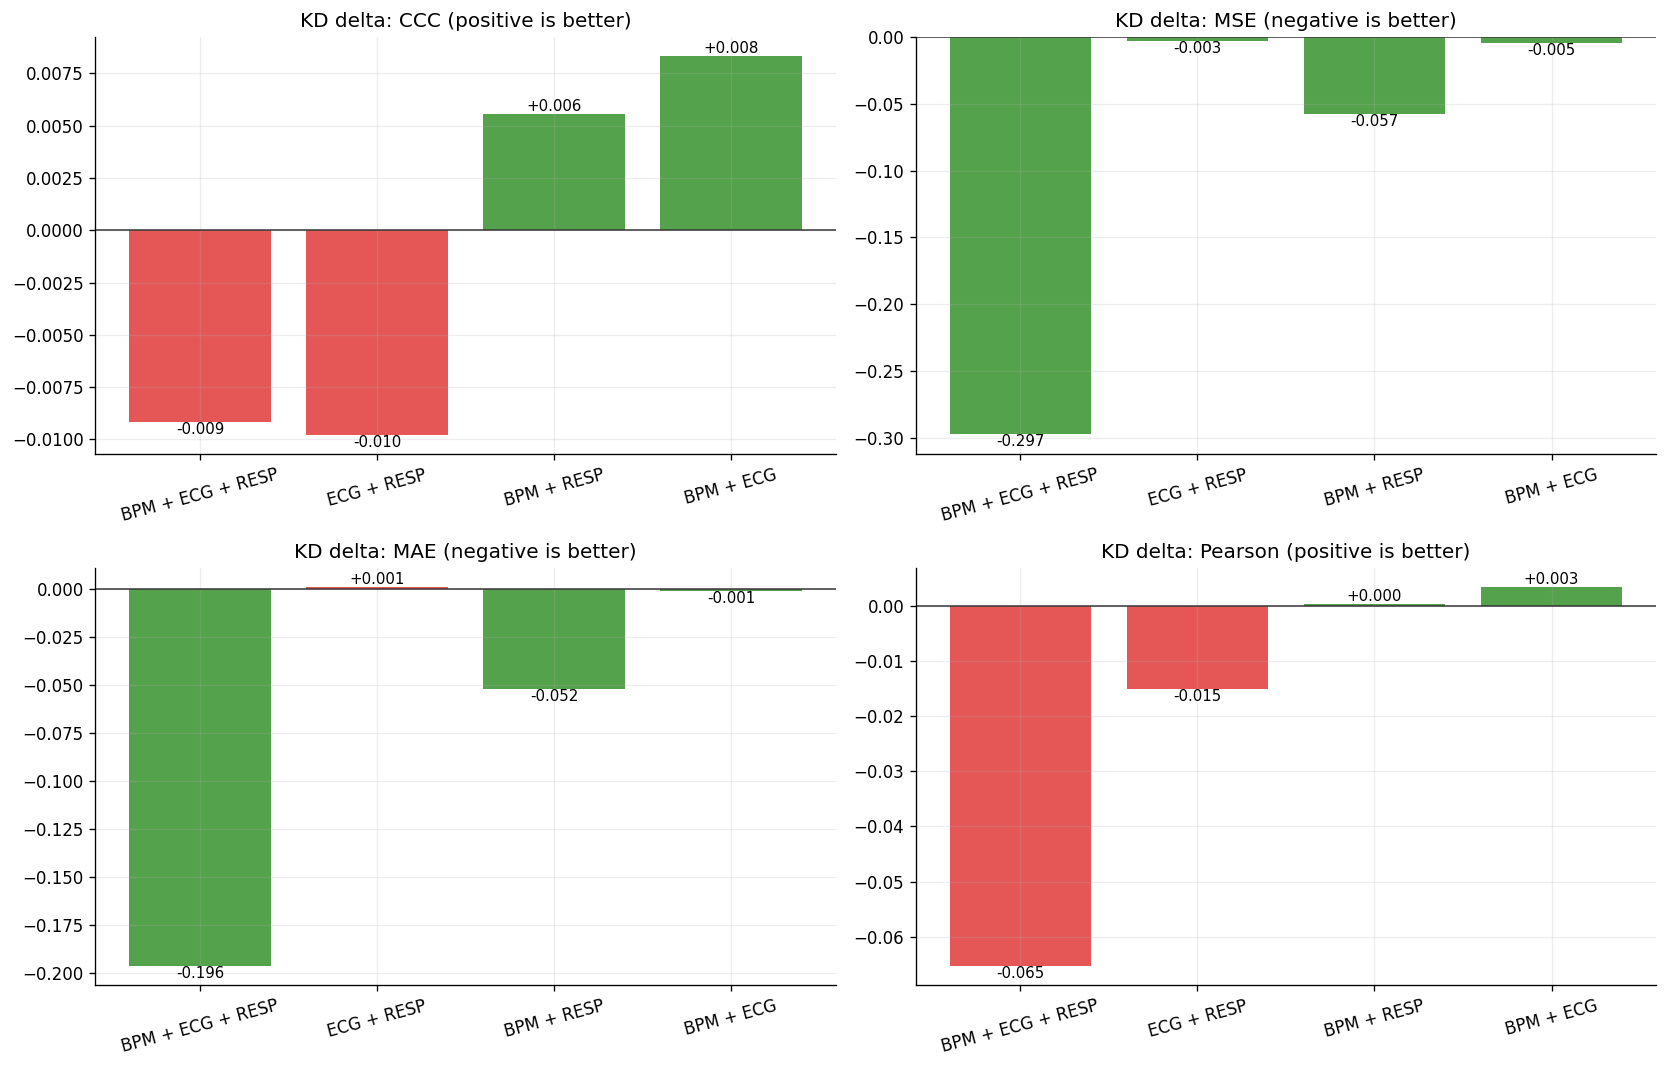

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\04_small_student_kd_vs_no_kd_deltas.png


,available_modalities,no_kd_ccc,kd_ccc,ccc_delta,no_kd_mse,kd_mse,mse_delta,no_kd_mae,kd_mae,mae_delta
0,BPM + ECG + RESP,0.208552,0.199364,-0.009188,0.542295,0.244818,-0.297477,0.579393,0.383044,-0.196348
1,ECG + RESP,0.112136,0.102347,-0.009789,0.228560,0.225323,-0.003237,0.379207,0.380310,0.001103
2,BPM + RESP,0.124443,0.130009,0.005566,0.378240,0.320876,-0.057364,0.468636,0.416688,-0.051948
3,BPM + ECG,0.316734,0.325058,0.008323,0.196515,0.191864,-0.004651,0.344066,0.342891,-0.001175


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric in zip(axes.flat, ["ccc", "mse", "mae", "pearson"]):
    delta_col = f"{metric}_delta"
    values = small_kd_delta[delta_col]
    if metric in {"mse", "mae"}:
        colors = ["#54a24b" if value <= 0 else "#e45756" for value in values]
        helpful = "negative is better"
    else:
        colors = ["#54a24b" if value >= 0 else "#e45756" for value in values]
        helpful = "positive is better"
    bars = ax.bar(small_kd_delta["available_modalities"], values, color=colors)
    ax.axhline(0, color="#333333", linewidth=0.9)
    ax.set_title(f"KD delta: {METRICS[metric]['label']} ({helpful})")
    ax.tick_params(axis="x", rotation=15)
    for bar, value in zip(bars, values):
        va = "bottom" if value >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:+.3f}", ha="center", va=va, fontsize=9)
savefig("04_small_student_kd_vs_no_kd_deltas.png")

display(small_kd_delta[[
    "available_modalities", "no_kd_ccc", "kd_ccc", "ccc_delta",
    "no_kd_mse", "kd_mse", "mse_delta",
    "no_kd_mae", "kd_mae", "mae_delta",
]])

## 5. Capacity Graphs

These graphs compare teacher-sized KD students against small KD students under the same missing-modality inputs.

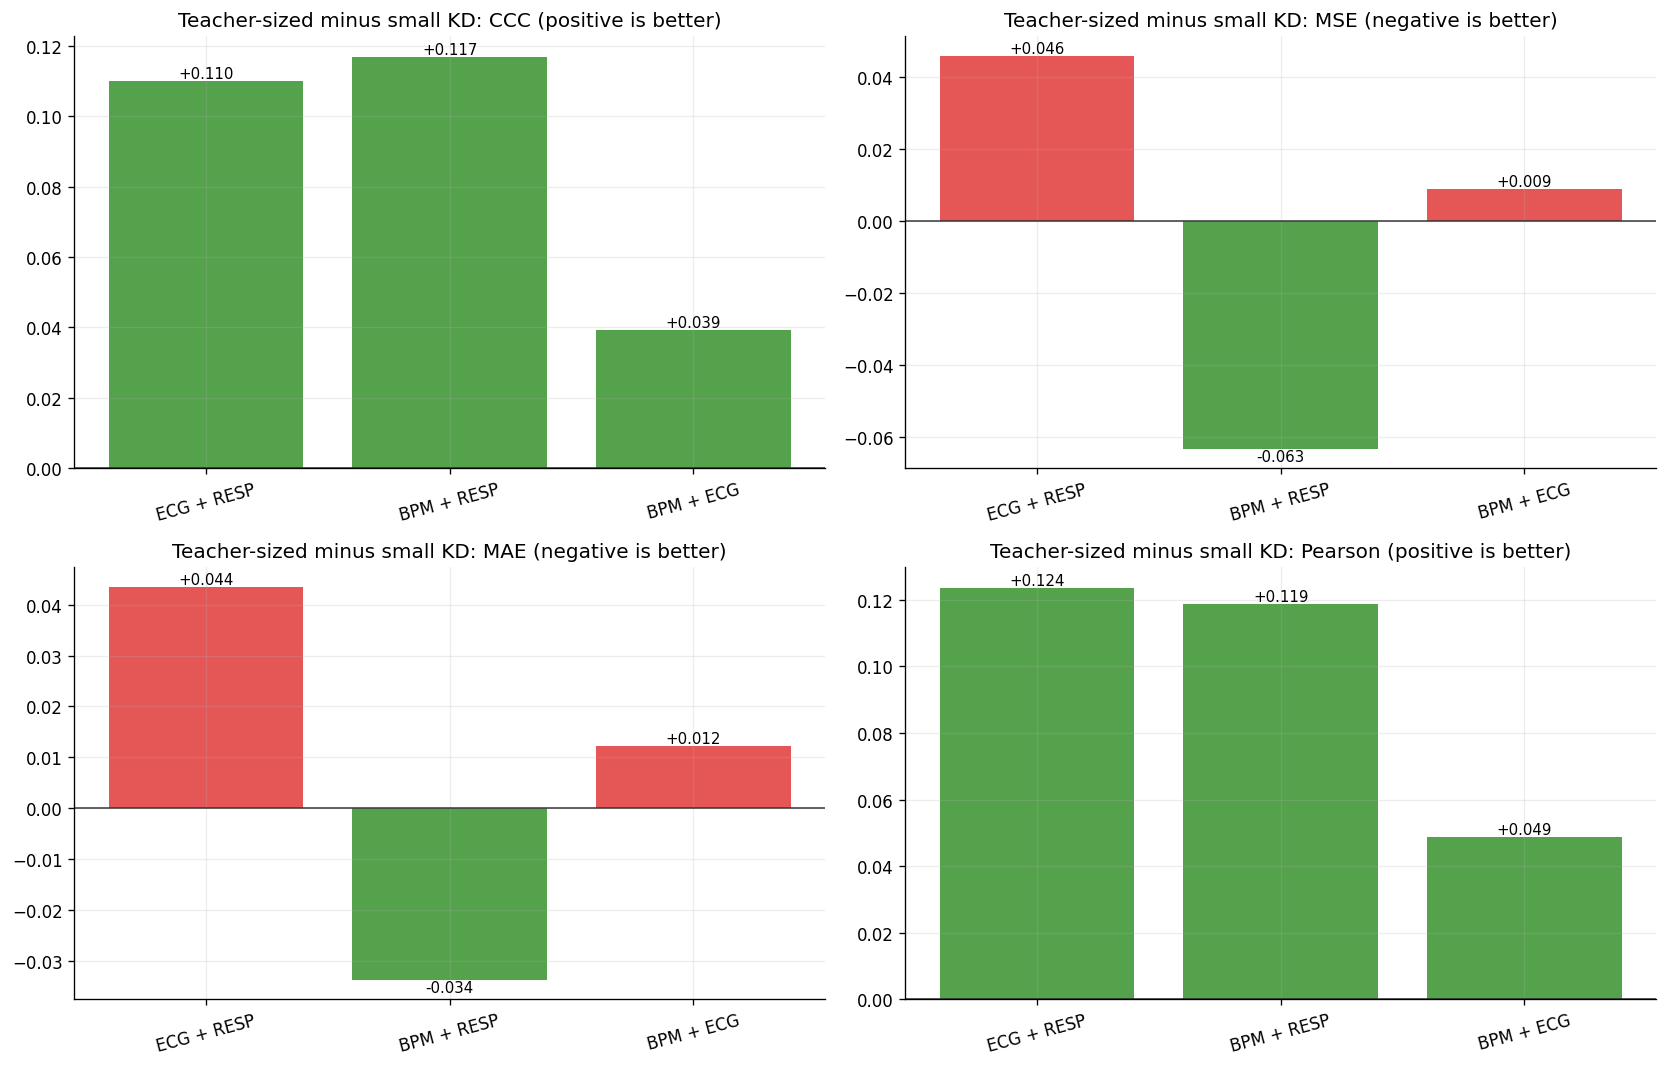

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\05_teacher_sized_capacity_deltas.png


,condition,condition_label,available_modalities,small_kd_ccc,teacher_sized_kd_ccc,ccc_delta,small_kd_mse,teacher_sized_kd_mse,mse_delta,small_kd_mae,teacher_sized_kd_mae,mae_delta,small_kd_pearson,teacher_sized_kd_pearson,pearson_delta,small_kd_mean_participant_ccc,teacher_sized_kd_mean_participant_ccc,mean_participant_ccc_delta
0,missing_bpm,Missing BPM,ECG + RESP,0.102347,0.212279,0.109933,0.225323,0.271177,0.045854,0.380310,0.423851,0.043541,0.120787,0.244443,0.123656,0.006784,0.007513,0.000729
1,missing_ecg,Missing ECG,BPM + RESP,0.130009,0.246920,0.116911,0.320876,0.257720,-0.063156,0.416688,0.382943,-0.033746,0.136561,0.255179,0.118618,-0.002130,-0.000067,0.002063
2,missing_resp,Missing RESP,BPM + ECG,0.325058,0.364222,0.039164,0.191864,0.200656,0.008792,0.342891,0.355126,0.012235,0.326643,0.375373,0.048730,-0.000565,0.086136,0.086701


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, metric in zip(axes.flat, ["ccc", "mse", "mae", "pearson"]):
    delta_col = f"{metric}_delta"
    values = capacity_delta[delta_col]
    if metric in {"mse", "mae"}:
        colors = ["#54a24b" if value <= 0 else "#e45756" for value in values]
        helpful = "negative is better"
    else:
        colors = ["#54a24b" if value >= 0 else "#e45756" for value in values]
        helpful = "positive is better"
    bars = ax.bar(capacity_delta["available_modalities"], values, color=colors)
    ax.axhline(0, color="#333333", linewidth=0.9)
    ax.set_title(f"Teacher-sized minus small KD: {METRICS[metric]['label']} ({helpful})")
    ax.tick_params(axis="x", rotation=15)
    for bar, value in zip(bars, values):
        va = "bottom" if value >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width() / 2, value, f"{value:+.3f}", ha="center", va=va, fontsize=9)
savefig("05_teacher_sized_capacity_deltas.png")

display(capacity_delta)

## 6. Heatmaps

Heatmaps make the broad pattern easy to scan: modality pair on one axis, model family on the other.

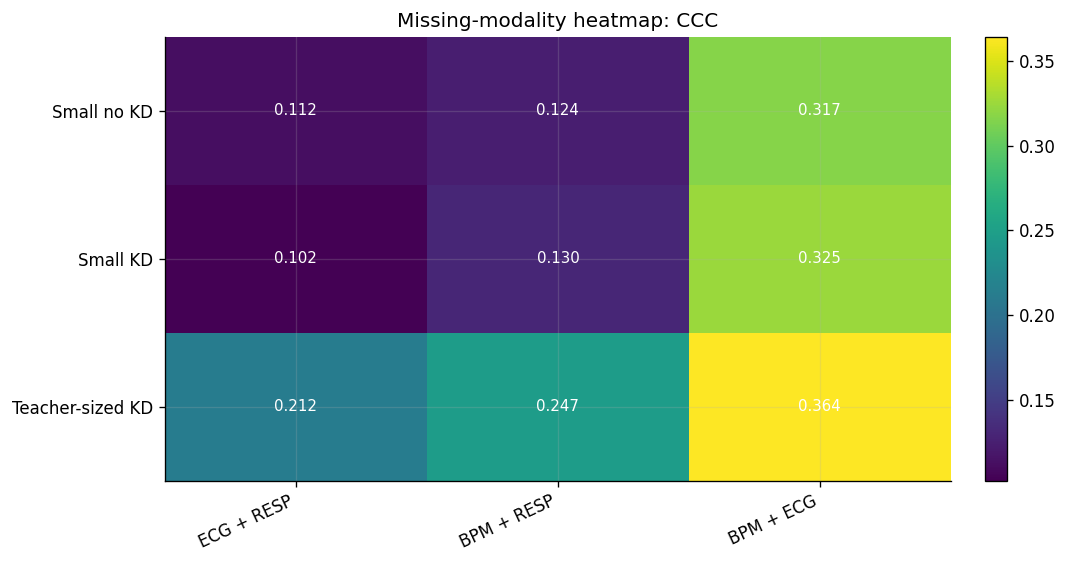

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\06_heatmap_ccc.png


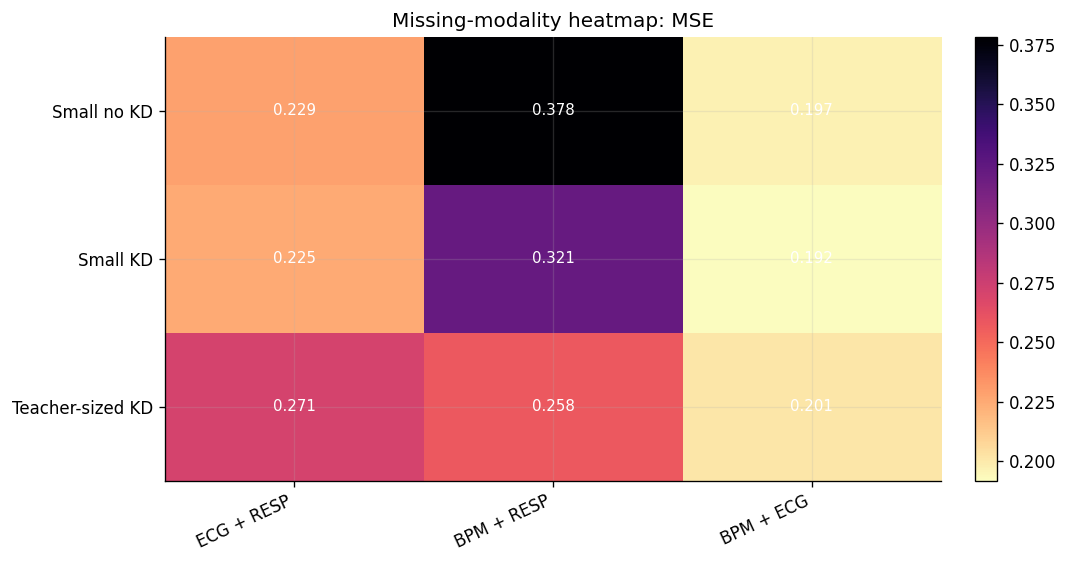

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\06_heatmap_mse.png


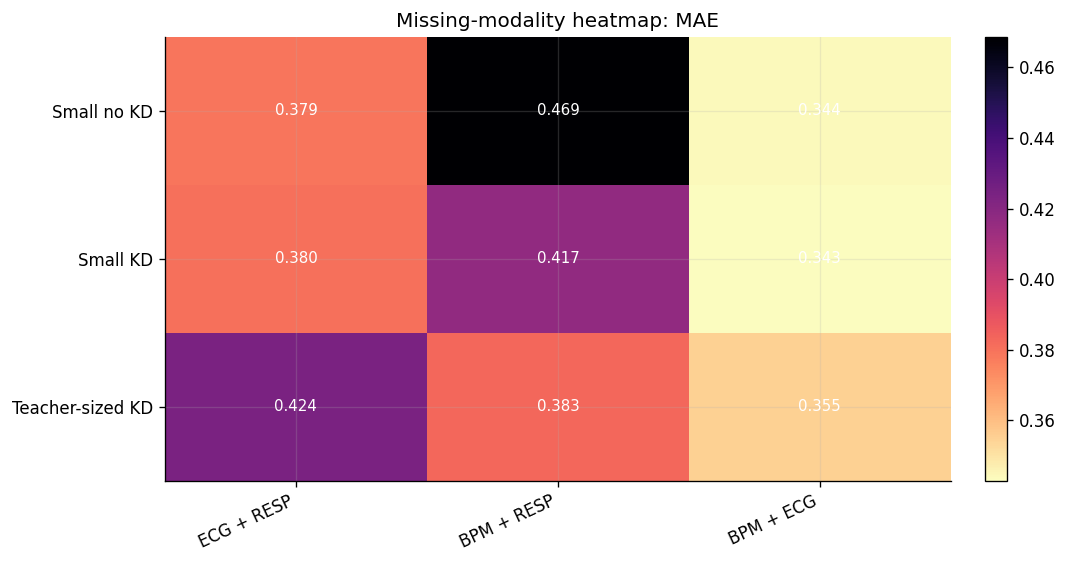

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\06_heatmap_mae.png


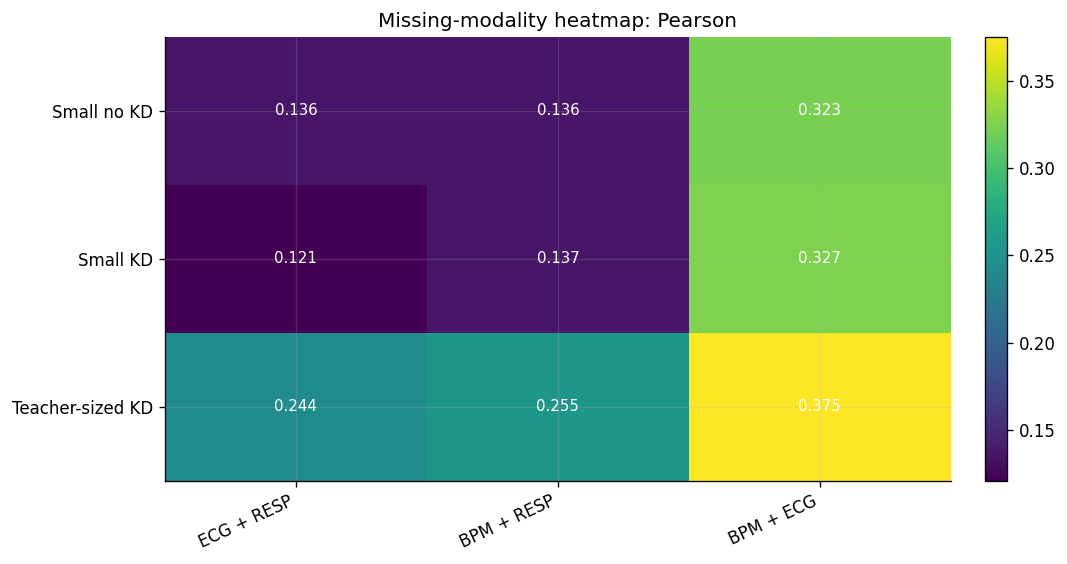

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\06_heatmap_pearson.png


In [10]:
for metric, cmap in [("ccc", "viridis"), ("mse", "magma_r"), ("mae", "magma_r"), ("pearson", "viridis")]:
    pivot = (
        missing
        .pivot_table(index="family", columns="available_modalities_text", values=metric, aggfunc="first")
        .reindex(index=family_order, columns=condition_labels)
    )
    plot_heatmap(pivot, f"Missing-modality heatmap: {METRICS[metric]['label']}", cmap=cmap)
    savefig(f"06_heatmap_{metric}.png")

## 7. Training-Curve Graphs

These graphs show whether performance was stable or noisy across epochs.

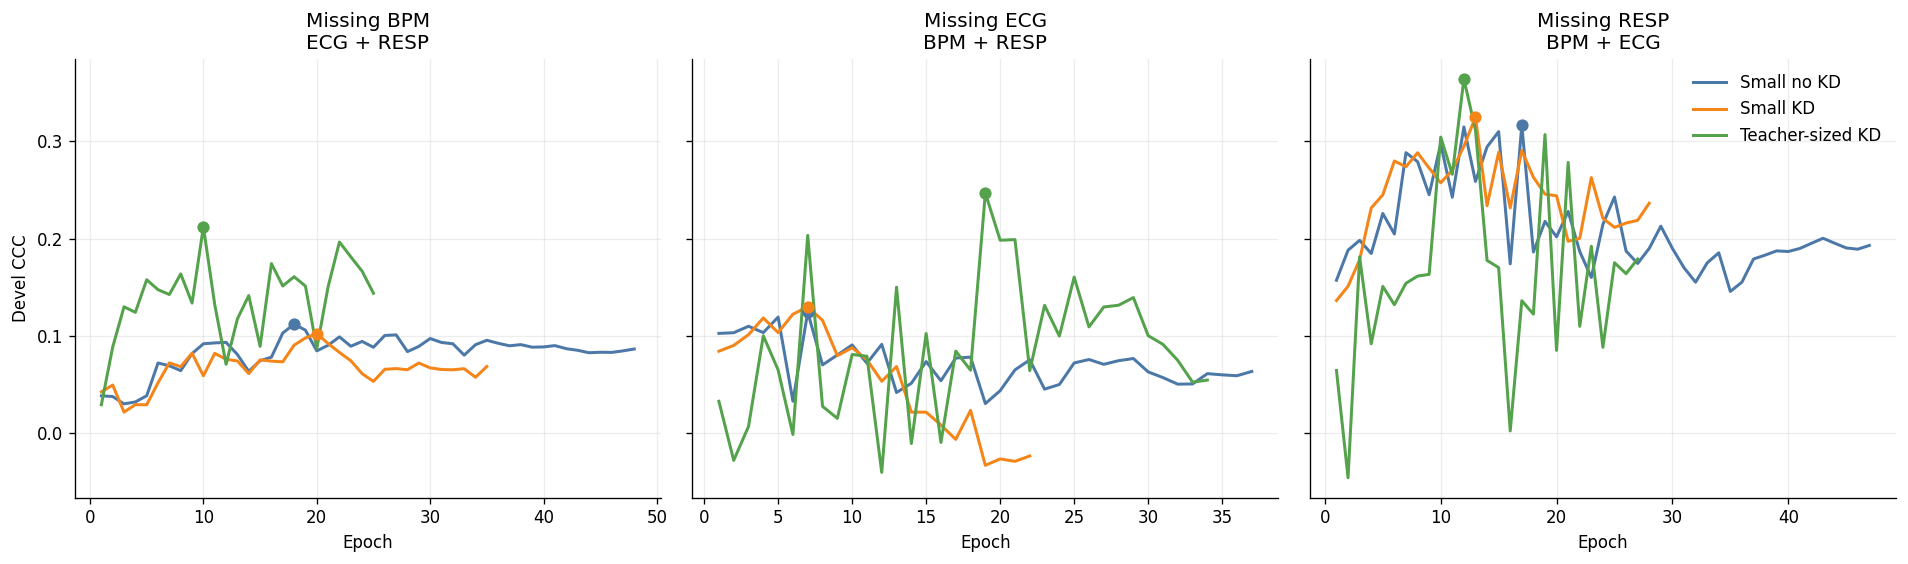

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\07_training_curves_devel_ccc_missing_modalities.png


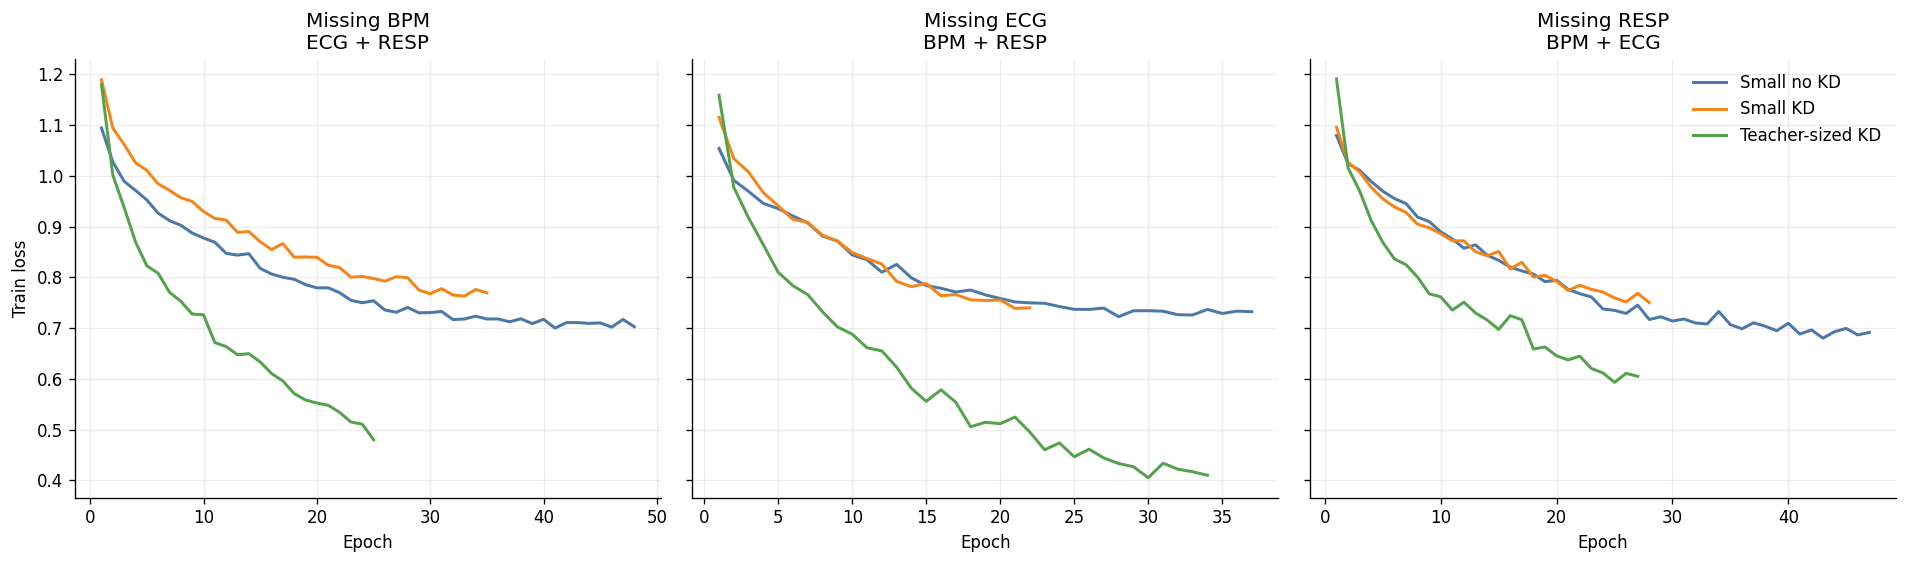

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\08_training_curves_train_loss_missing_modalities.png


WindowsPath('C:/Users/Victus/Documents/GitHub/Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition/outputs/eda_pipeline_report/notebook_graphs/08_training_curves_train_loss_missing_modalities.png')

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, condition in zip(axes, CONDITION_ORDER):
    subset = histories[histories["condition"] == condition]
    for family in family_order:
        run = subset[subset["family"] == family]
        if run.empty:
            continue
        ax.plot(run["epoch"], run["devel_ccc"], label=family, color=FAMILY_COLORS[family], linewidth=1.8)
        best = run.loc[run["devel_ccc"].idxmax()]
        ax.scatter([best["epoch"]], [best["devel_ccc"]], color=FAMILY_COLORS[family], s=40, zorder=3)
    ax.set_title(f"{CONDITION_LABELS[condition]}\n{AVAILABLE_LABELS[condition]}")
    ax.set_xlabel("Epoch")
axes[0].set_ylabel("Devel CCC")
axes[-1].legend(frameon=False)
savefig("07_training_curves_devel_ccc_missing_modalities.png")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
for ax, condition in zip(axes, CONDITION_ORDER):
    subset = histories[histories["condition"] == condition]
    for family in family_order:
        run = subset[subset["family"] == family]
        if run.empty or "train_loss" not in run:
            continue
        ax.plot(run["epoch"], run["train_loss"], label=family, color=FAMILY_COLORS[family], linewidth=1.8)
    ax.set_title(f"{CONDITION_LABELS[condition]}\n{AVAILABLE_LABELS[condition]}")
    ax.set_xlabel("Epoch")
axes[0].set_ylabel("Train loss")
axes[-1].legend(frameon=False)
savefig("08_training_curves_train_loss_missing_modalities.png")

## 8. Knowledge-Distillation Loss Graphs

These graphs inspect KD training internals where relation loss is available.

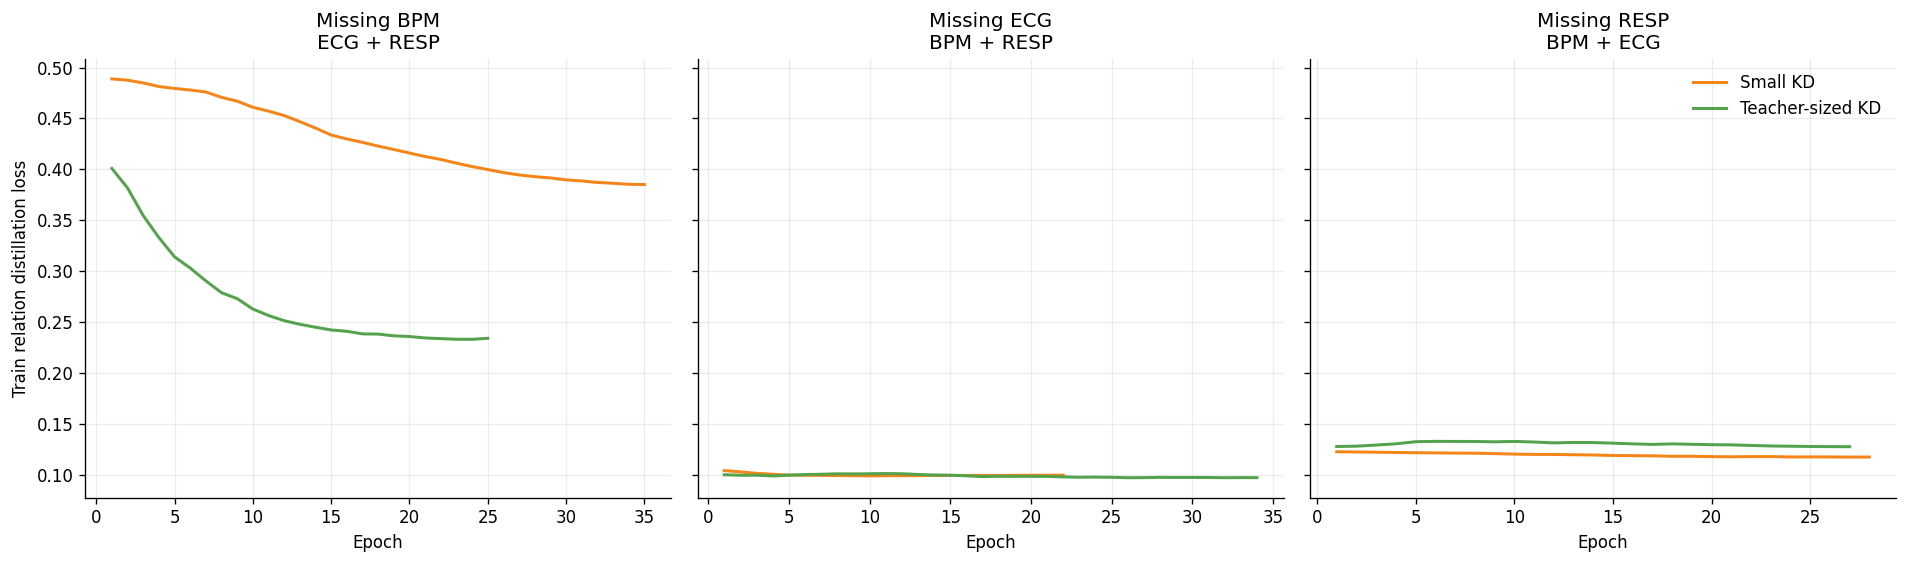

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\09_kd_relation_loss_curves.png


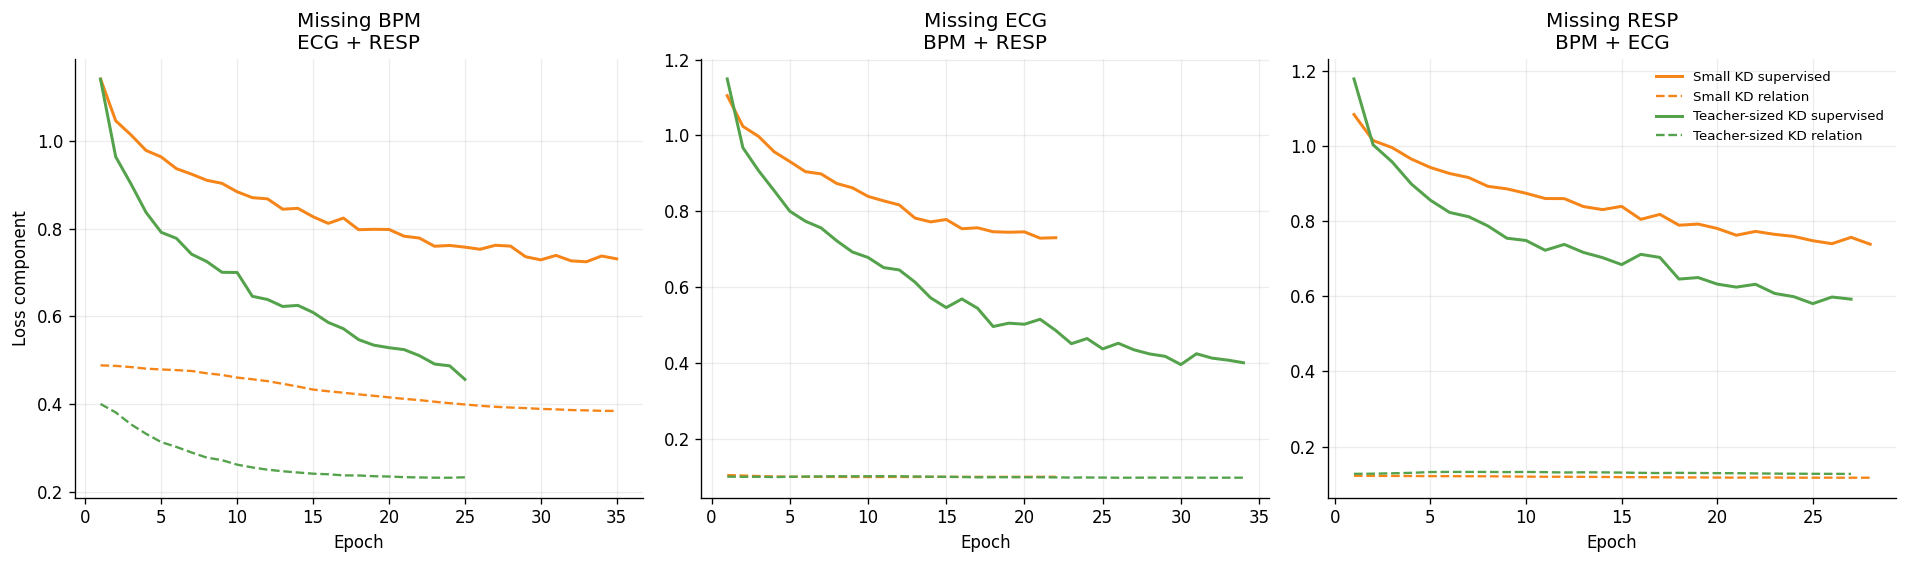

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\10_kd_supervised_vs_relation_loss.png


In [12]:
kd_histories = histories[histories["train_relation_distillation_loss"].notna()].copy() if "train_relation_distillation_loss" in histories else pd.DataFrame()

if kd_histories.empty:
    display(Markdown("No KD relation-loss histories found."))
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=True)
    for ax, condition in zip(axes, CONDITION_ORDER):
        subset = kd_histories[kd_histories["condition"] == condition]
        for family in ["Small KD", "Teacher-sized KD"]:
            run = subset[subset["family"] == family]
            if run.empty:
                continue
            ax.plot(run["epoch"], run["train_relation_distillation_loss"], label=family, color=FAMILY_COLORS[family], linewidth=1.8)
        ax.set_title(f"{CONDITION_LABELS[condition]}\n{AVAILABLE_LABELS[condition]}")
        ax.set_xlabel("Epoch")
    axes[0].set_ylabel("Train relation distillation loss")
    axes[-1].legend(frameon=False)
    savefig("09_kd_relation_loss_curves.png")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharey=False)
    for ax, condition in zip(axes, CONDITION_ORDER):
        subset = kd_histories[kd_histories["condition"] == condition]
        for family in ["Small KD", "Teacher-sized KD"]:
            run = subset[subset["family"] == family]
            if run.empty:
                continue
            ax.plot(run["epoch"], run["train_supervised_loss"], label=f"{family} supervised", color=FAMILY_COLORS[family], linewidth=1.8)
            ax.plot(run["epoch"], run["train_relation_distillation_loss"], label=f"{family} relation", color=FAMILY_COLORS[family], linestyle="--", linewidth=1.4)
        ax.set_title(f"{CONDITION_LABELS[condition]}\n{AVAILABLE_LABELS[condition]}")
        ax.set_xlabel("Epoch")
    axes[0].set_ylabel("Loss component")
    axes[-1].legend(frameon=False, fontsize=8)
    savefig("10_kd_supervised_vs_relation_loss.png")

## 9. Efficiency and Tradeoff Graphs

These plots compare model size, CCC-per-parameter, and metric tradeoffs.

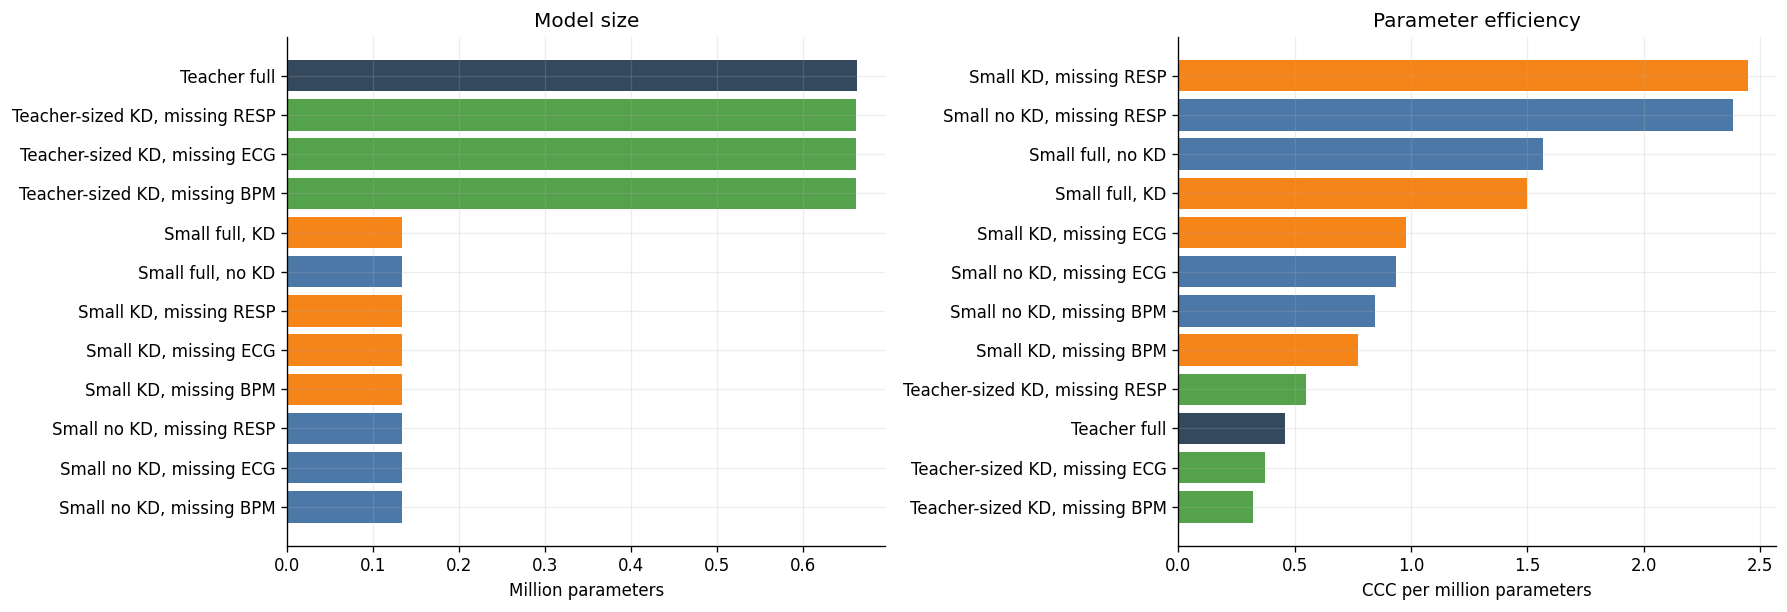

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\11_parameter_count_and_efficiency.png


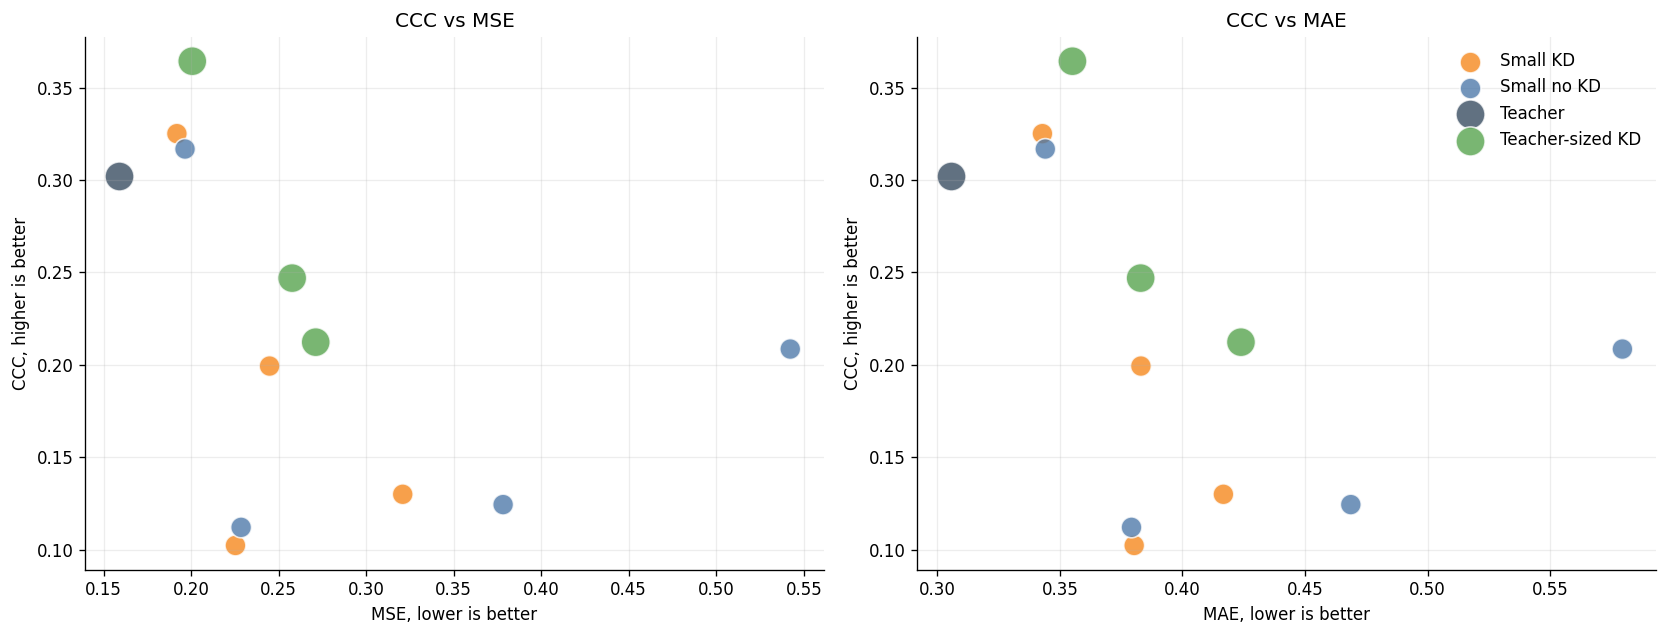

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\12_metric_tradeoff_scatter.png


WindowsPath('C:/Users/Victus/Documents/GitHub/Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition/outputs/eda_pipeline_report/notebook_graphs/12_metric_tradeoff_scatter.png')

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

data = results.sort_values("parameter_count")
axes[0].barh(data["display_name"], data["parameter_millions"], color=[FAMILY_COLORS.get(f, "#888888") for f in data["family"]])
axes[0].set_xlabel("Million parameters")
axes[0].set_title("Model size")

eff = results.sort_values("ccc_per_million_params")
axes[1].barh(eff["display_name"], eff["ccc_per_million_params"], color=[FAMILY_COLORS.get(f, "#888888") for f in eff["family"]])
axes[1].set_xlabel("CCC per million parameters")
axes[1].set_title("Parameter efficiency")

savefig("11_parameter_count_and_efficiency.png")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
for family, group in results.groupby("family"):
    axes[0].scatter(group["mse"], group["ccc"], s=120 + group["parameter_millions"] * 280, color=FAMILY_COLORS.get(family, "#888888"), alpha=0.78, label=family, edgecolor="white")
    axes[1].scatter(group["mae"], group["ccc"], s=120 + group["parameter_millions"] * 280, color=FAMILY_COLORS.get(family, "#888888"), alpha=0.78, label=family, edgecolor="white")
axes[0].set_xlabel("MSE, lower is better")
axes[0].set_ylabel("CCC, higher is better")
axes[0].set_title("CCC vs MSE")
axes[1].set_xlabel("MAE, lower is better")
axes[1].set_ylabel("CCC, higher is better")
axes[1].set_title("CCC vs MAE")
axes[1].legend(frameon=False)
savefig("12_metric_tradeoff_scatter.png")

## 10. Epoch and Checkpoint Graphs

These show how long each run trained and where the best checkpoint appeared.

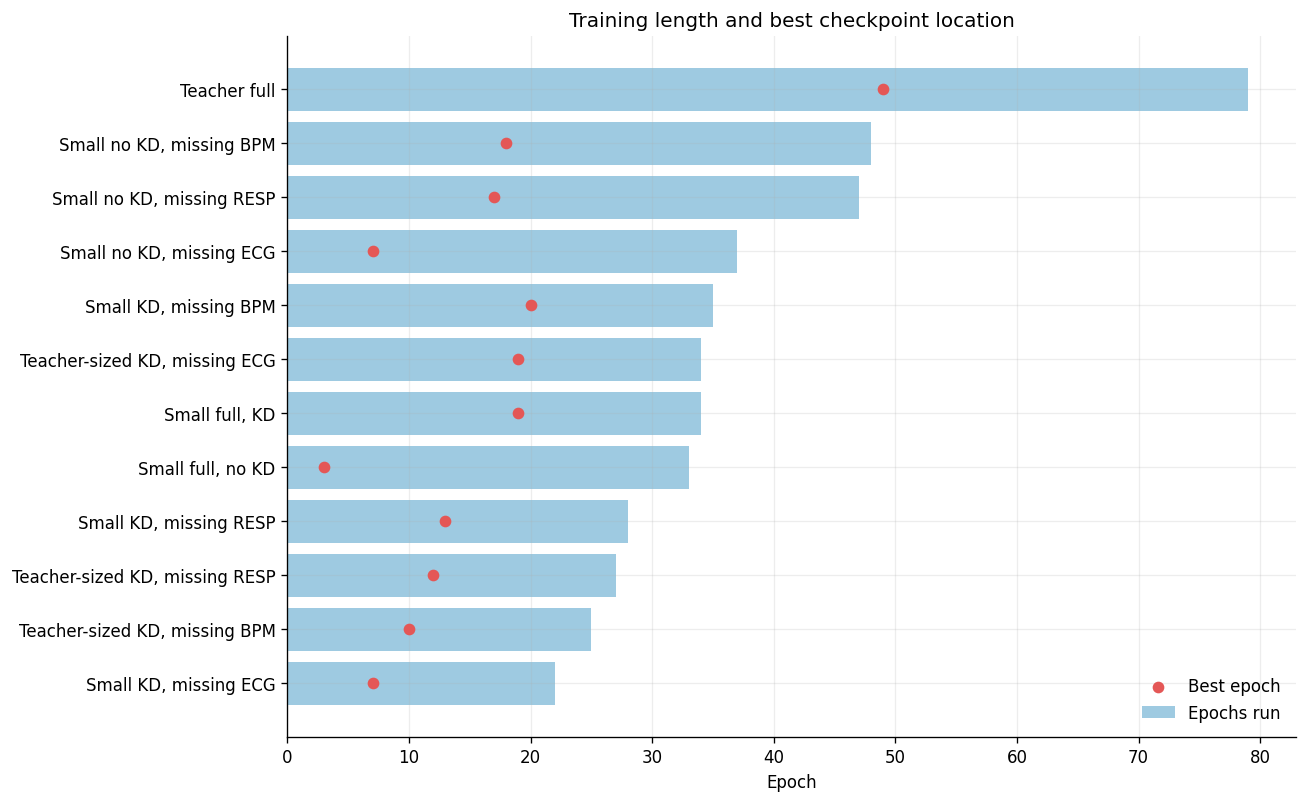

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\13_epochs_run_and_best_epoch.png


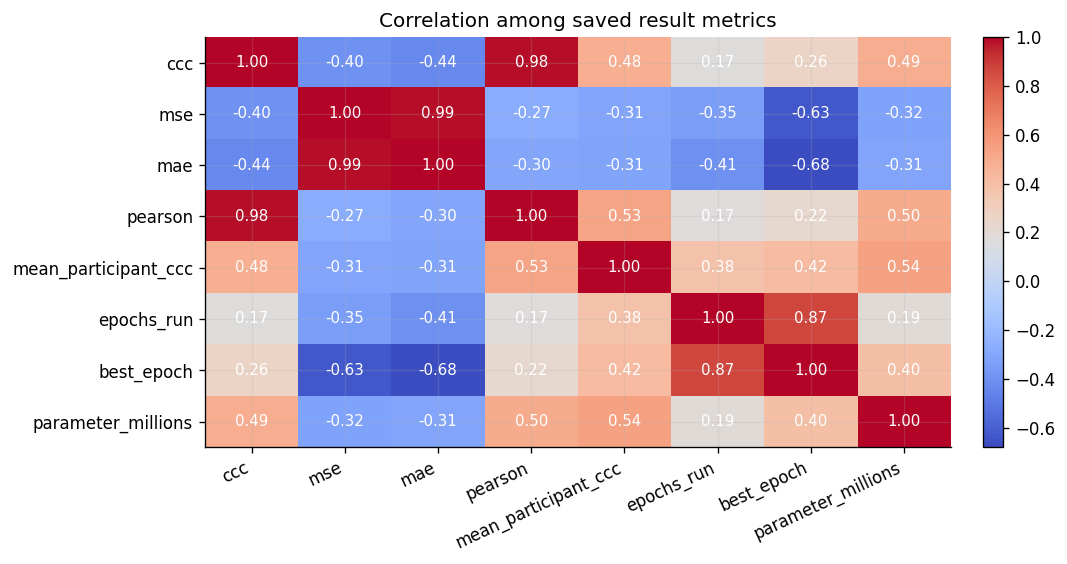

saved: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\14_metric_correlation_heatmap.png


WindowsPath('C:/Users/Victus/Documents/GitHub/Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition/outputs/eda_pipeline_report/notebook_graphs/14_metric_correlation_heatmap.png')

In [14]:
data = results.sort_values("epochs_run")
fig, ax = plt.subplots(figsize=(11, 6.8))
ax.barh(data["display_name"], data["epochs_run"], color="#9ecae1", label="Epochs run")
ax.scatter(data["best_epoch"], data["display_name"], color="#e45756", label="Best epoch", zorder=3)
ax.set_xlabel("Epoch")
ax.set_title("Training length and best checkpoint location")
ax.legend(frameon=False)
savefig("13_epochs_run_and_best_epoch.png")

metric_data = results[["ccc", "mse", "mae", "pearson", "mean_participant_ccc", "epochs_run", "best_epoch", "parameter_millions"]].corr(numeric_only=True)
plot_heatmap(metric_data, "Correlation among saved result metrics", cmap="coolwarm", fmt=".2f")
savefig("14_metric_correlation_heatmap.png")

## 11. Dynamic Conclusions

This cell summarizes the current evidence from the saved run artifacts.

In [15]:
best = results.sort_values("ccc", ascending=False).iloc[0]
full_no_kd = results[results["run_name"] == "student_full_no_kd"].iloc[0]
full_kd = results[results["run_name"] == "student_full_kd"].iloc[0]

kd_positive = small_kd_delta[small_kd_delta["ccc_delta"] > 0]
kd_negative = small_kd_delta[small_kd_delta["ccc_delta"] <= 0]

summary = f'''
### Summary

- Best saved model by devel CCC: **{best.display_name}** with **CCC={best.ccc:.4f}**.
- Best saved model uses **{best.available_modalities_text}**.
- Full-input small KD did **not** beat the full-input no-KD small student on CCC:
  **{full_kd.ccc:.4f}** vs **{full_no_kd.ccc:.4f}**.
- Small-student KD improved CCC for: **{", ".join(kd_positive["available_modalities"].tolist()) or "none"}**.
- Small-student KD did not improve CCC for: **{", ".join(kd_negative["available_modalities"].tolist()) or "none"}**.
- Across missing-modality runs, **BPM + ECG** is strongest in this seed; removing RESP hurts least.
- Teacher-sized KD improves CCC over small KD for all missing-modality cases.

Current verdict: **partially supported**. KD and missing-modality infrastructure works, and KD can help under some missing-modality settings, especially with larger student capacity. The broad claim that KD consistently improves a compressed student still needs repeated seeds and KD hyperparameter ablations.
'''
display(Markdown(summary))

index_lines = ["# Notebook Graph Index", ""]
for path in sorted(NOTEBOOK_OUTPUT_DIR.glob("*.png")):
    index_lines.append(f"- [{path.name}]({path.as_posix()})")
(NOTEBOOK_OUTPUT_DIR / "graph_index.md").write_text("\n".join(index_lines), encoding="utf-8")
print("Graph index:", NOTEBOOK_OUTPUT_DIR / "graph_index.md")


### Summary

- Best saved model by devel CCC: **Teacher-sized KD, missing RESP** with **CCC=0.3642**.
- Best saved model uses **BPM + ECG**.
- Full-input small KD did **not** beat the full-input no-KD small student on CCC:
  **0.1994** vs **0.2086**.
- Small-student KD improved CCC for: **BPM + RESP, BPM + ECG**.
- Small-student KD did not improve CCC for: **BPM + ECG + RESP, ECG + RESP**.
- Across missing-modality runs, **BPM + ECG** is strongest in this seed; removing RESP hurts least.
- Teacher-sized KD improves CCC over small KD for all missing-modality cases.

Current verdict: **partially supported**. KD and missing-modality infrastructure works, and KD can help under some missing-modality settings, especially with larger student capacity. The broad claim that KD consistently improves a compressed student still needs repeated seeds and KD hyperparameter ablations.


Graph index: C:\Users\Victus\Documents\GitHub\Knowledge-Distillation-for-Robust-Physiological-Affect-Recognition\outputs\eda_pipeline_report\notebook_graphs\graph_index.md
